In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("housing.csv")

In [4]:
df['income_cat']=pd.cut(df['median_income'],bins=[0,1.5,3.0,4.5,6.0,np.inf],labels=[1,2,3,4,5])

In [12]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1 ,test_size=0.2,random_state=42)
for train_index,test_index in split.split(df,df['income_cat']):
    strat_train_set=df.loc[train_index ]
    strat_test_set=df.loc[test_index ]
    

In [16]:
#lets remove the income_cat column
for set in (strat_train_set,strat_test_set):
    set.drop("income_cat",axis=1,inplace=True)
    

In [18]:
df=strat_train_set.copy() # here we create a copy of train set and store it in df.
# now we work in df which is copy of train set .
# and a important point , when ever you work with your data you have to work with your training data ,dont touch testing data .

<Axes: xlabel='latitude', ylabel='longitude'>

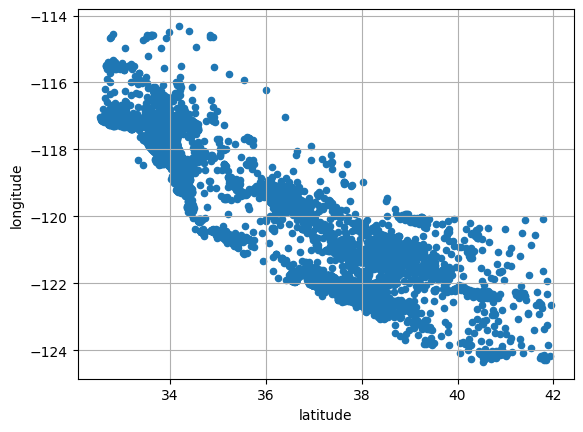

In [19]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True)
#Geographical Scatter Plot

<Axes: xlabel='latitude', ylabel='longitude'>

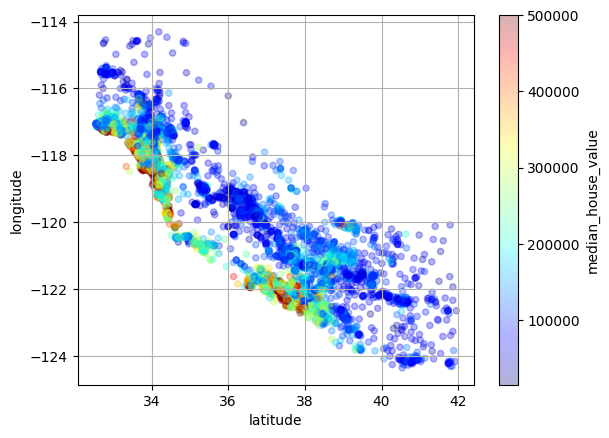

In [21]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True,alpha=0.3,cmap="jet", c="median_house_value") # increase visiblity and fade from overlapping .

<Axes: xlabel='latitude', ylabel='longitude'>

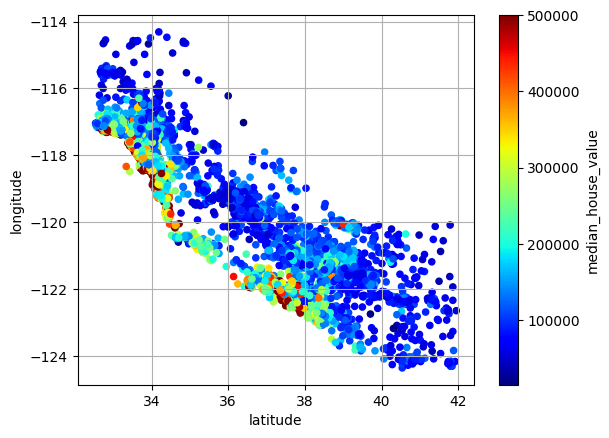

In [22]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True,cmap="jet", c="median_house_value") # i remove alpha to see it clearly .

In [23]:
df.drop("ocean_proximity",inplace=True,axis=1) # here we remove the "ocean_proximity" column to find co-relation.

In [24]:
df.corr() # to find the co-relation .
#Correlation Matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


array([[<Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>]],
      dtype=object)

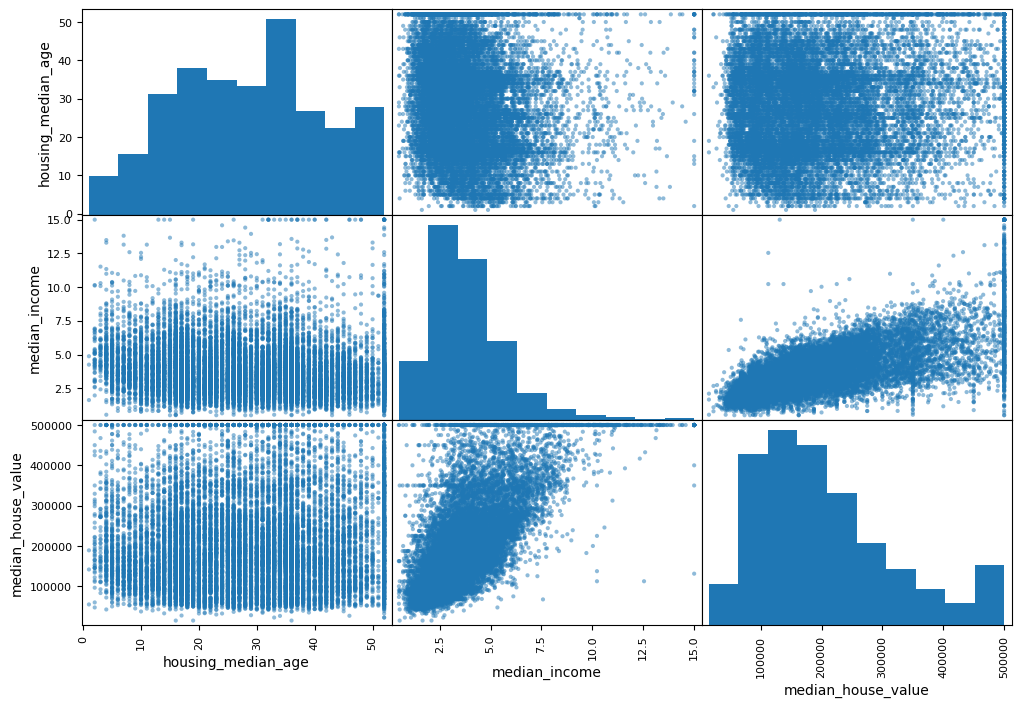

In [28]:
#Scatter Matrix
from pandas.plotting import scatter_matrix 
attributes =["housing_median_age","median_income","median_house_value"]
scatter_matrix(df[attributes],figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

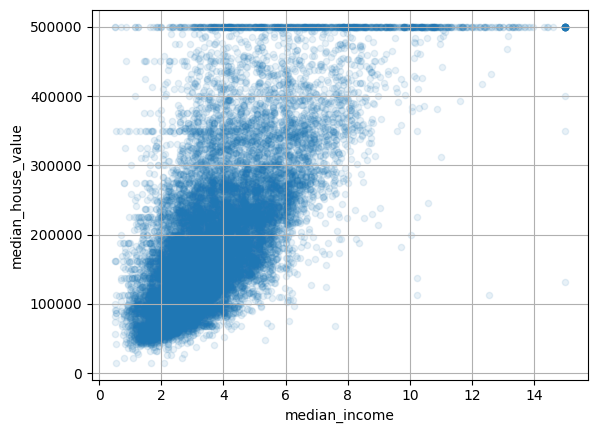

In [29]:
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)